# RootList Sequence Predictor (Migrated)

Refactored version of `sequence_predictor.ipynb`.  All model, data-loading,
training, and evaluation logic lives in `python_model.core.sequence_*` modules.
This notebook is a thin driver that wires the components together.

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from dotenv import load_dotenv

# --- path setup ---
project_root = Path.cwd().parent.parent.parent
ml_pipeline_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(ml_pipeline_root))
sys.path.insert(0, str(project_root / 'ml' / 'neo4j'))

from neo4jClient import Neo4jClient

# --- .env ---
for p in [Path('.env'), Path('../.env'), Path('../../.env'), Path('../../../.env')]:
    if p.exists():
        load_dotenv(p, override=True)
        print(f'Loaded .env from: {p.absolute()}')
        break
else:
    print('Warning: No .env file found')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {device}')

Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\..\..\.env
PyTorch 2.10.0+cu126  |  device: cuda


## 2. Configuration

In [2]:
from python_model.core.sequence_config import SequencePredictorConfig, RootListTokenizer

config = SequencePredictorConfig()

print('Configuration:')
print(f'  Context window:   {config.context_window_size}')
print(f'  Vocabulary size:  {config.vocab_size}')
print(f'  SOS token ID:     {config.sos_token_id}')
print(f'  PAD token ID:     {config.pad_token_id}')
print(f'  Hidden dim:       {config.hidden_dim}')
print(f'  Encoder type:     {config.encoder_type}')
print(f'  Max epochs:       {config.max_epochs}')
print(f'  Patience:         {config.patience}')

Configuration:
  Context window:   8
  Vocabulary size:  134
  SOS token ID:     132
  PAD token ID:     133
  Hidden dim:       64
  Encoder type:     gcn
  Max epochs:       100
  Patience:         10


## 3. Tokenizer

In [3]:
tokenizer = RootListTokenizer(config)

test_roots = [-3, 0, 5, 12]
encoded = tokenizer.encode_sequence(test_roots)
decoded = tokenizer.decode_sequence(encoded)
print(f'Round-trip: {test_roots} -> {encoded.tolist()} -> {decoded}')
assert decoded == test_roots, 'tokenizer round-trip failed'

Round-trip: [-3, 0, 5, 12] -> [132, 79, 82, 87, 94] -> [-3, 0, 5, 12]


## 4. Data Loading

In [4]:
from python_model.core.sequence_data_loader import SequenceDataLoader

NEO4J_URI      = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER     = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE', 'd4seed1')

print(f'URI:  {NEO4J_URI}')
print(f'User: {NEO4J_USER}')
print(f'DB:   {NEO4J_DATABASE}')

if not NEO4J_PASSWORD:
    raise ValueError('NEO4J_PASSWORD not set')

client = Neo4jClient(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)
loader = SequenceDataLoader(client, NEO4J_DATABASE, config)
loader.load()

train_dataset, val_dataset, test_dataset = loader.create_sequence_dataset()

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=config.batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=config.batch_size, shuffle=False)

print(f'\nData loaders: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)} batches')

URI:  bolt://localhost:7687
User: neo4j
DB:   d5seed1
Loading ALL nodes from Neo4j (full graph for GCN embeddings)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 6 )\n     //WHERE ( all(x IN c

  Loaded 3669 total nodes
  Built feature matrix for full graph: torch.Size([3669, 16])
Loading ALL edges from Neo4j (full graph for GCN)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 6)\n     //WHERE ( all(x IN cb.pArrayLi

  Loaded 7336 edges (undirected)
Loading wNum=0 nodes for sequence prediction...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=14, column=1, offset=397>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 397, 'line': 14, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n//MATCH (d:Dnode)-[:CreatedBye]->(cb:CreatedBy {wNum:0})\n//WHERE size(d.RootList) = d.totalZero\n//  AND all(x IN cb.pArrayList WHERE x >= 0 AND x < 7)\n//WITH DISTINCT d \n//RETURN elementId(d) as node_id,\n// 

  Loaded 20416 leaf nodes with complete RootLists
  Mapped 20416 sequence nodes to global indices
  RootList size distribution: min=1, max=5, mean=2.21
Created 20408 sequence samples (window size = 8)
  Using 20416 wNum=0 nodes from full graph of 3669 nodes
Split: train=14285, val=3061, test=3062

Data loaders: train=447, val=96, test=96 batches


## 5. Model

In [5]:
from python_model.core.sequence_models import SequencePredictor

model = SequencePredictor(config).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {num_params:,} trainable parameters')
print(f'  Node encoder:    {config.encoder_type.upper()}')
print(f'  Hidden dim:      {config.hidden_dim}')
print(f'  Encoder layers:  {config.num_encoder_layers}')
print(f'  Decoder layers:  {config.num_decoder_layers}')

Model: 256,780 trainable parameters
  Node encoder:    GCN
  Hidden dim:      64
  Encoder layers:  2
  Decoder layers:  2


## 6. Training

In [6]:
from python_model.core.sequence_trainer import train_model

pyg_data = loader.get_pyg_data()

model, history = train_model(
    model, train_loader, val_loader,
    pyg_data, tokenizer, config, device,
)

Starting training for up to 100 epochs...
  Early stopping patience: 10

Epoch   0 | Train Loss: 2.8159 (size: 1.2543, root: 1.5616) | Val Loss: 2.4011
Epoch   5 | Train Loss: 2.0287 (size: 1.1064, root: 0.9223) | Val Loss: 1.9348
Epoch  10 | Train Loss: 1.8426 (size: 1.0480, root: 0.7946) | Val Loss: 1.7304
Epoch  15 | Train Loss: 1.6878 (size: 0.9868, root: 0.7010) | Val Loss: 1.5277
Epoch  20 | Train Loss: 1.5939 (size: 0.9410, root: 0.6529) | Val Loss: 1.4556
Epoch  25 | Train Loss: 1.5408 (size: 0.9172, root: 0.6236) | Val Loss: 1.3505
Epoch  30 | Train Loss: 1.4813 (size: 0.8928, root: 0.5886) | Val Loss: 1.3481
Epoch  35 | Train Loss: 1.4543 (size: 0.8863, root: 0.5680) | Val Loss: 1.3126
Epoch  40 | Train Loss: 1.4136 (size: 0.8566, root: 0.5570) | Val Loss: 1.2135
Epoch  45 | Train Loss: 1.3879 (size: 0.8403, root: 0.5477) | Val Loss: 1.2130
Epoch  50 | Train Loss: 1.3353 (size: 0.8163, root: 0.5190) | Val Loss: 1.1404
Epoch  55 | Train Loss: 1.3198 (size: 0.8101, root: 0.5097

## 7. Evaluation

In [7]:
from python_model.core.sequence_trainer import (
    batch_predict,
    print_evaluation_report,
    print_per_size_analysis,
)

print('Generating predictions on test set...')
test_predictions = batch_predict(
    model, test_loader, pyg_data, tokenizer, config, device,
)
test_metrics = print_evaluation_report(test_predictions, 'Test')
print_per_size_analysis(test_predictions)

Generating predictions on test set...

Test Set Evaluation Report
Number of samples: 3062

Size Accuracy:     77.82%
Exact Match:       55.29%
Set Match:         55.62%
Element Accuracy:  57.38%

Example predictions:
  ✗ Pred: size=2, roots=[0, 1]
    True: size=2, roots=[5, 6]
  ✗ Pred: size=2, roots=[0, 1]
    True: size=1, roots=[0]
  ✗ Pred: size=5, roots=[2, 3, 4, 5, 6]
    True: size=5, roots=[0, 1, 2, 3, 9]
  ✓ Pred: size=2, roots=[2, 3]
    True: size=2, roots=[2, 3]
  ✓ Pred: size=1, roots=[5]
    True: size=1, roots=[5]

Exact Match Accuracy by True RootList Size:
----------------------------------------
  Size 1: 79.8% (1133/1419)
  Size 2: 49.6% (353/711)
  Size 3: 29.7% (105/353)
  Size 5: 17.6% (102/579)


In [8]:
print('Generating predictions on validation set...')
val_predictions = batch_predict(
    model, val_loader, pyg_data, tokenizer, config, device,
)
val_metrics = print_evaluation_report(val_predictions, 'Validation')

Generating predictions on validation set...

Validation Set Evaluation Report
Number of samples: 3061

Size Accuracy:     78.83%
Exact Match:       55.86%
Set Match:         56.32%
Element Accuracy:  55.43%

Example predictions:
  ✓ Pred: size=1, roots=[0]
    True: size=1, roots=[0]
  ✓ Pred: size=1, roots=[5]
    True: size=1, roots=[5]
  ✗ Pred: size=3, roots=[0, 1, 7]
    True: size=2, roots=[5, 8]
  ✗ Pred: size=1, roots=[4]
    True: size=2, roots=[4, 7]
  ✓ Pred: size=2, roots=[2, 3]
    True: size=2, roots=[2, 3]


## 8. Visualization

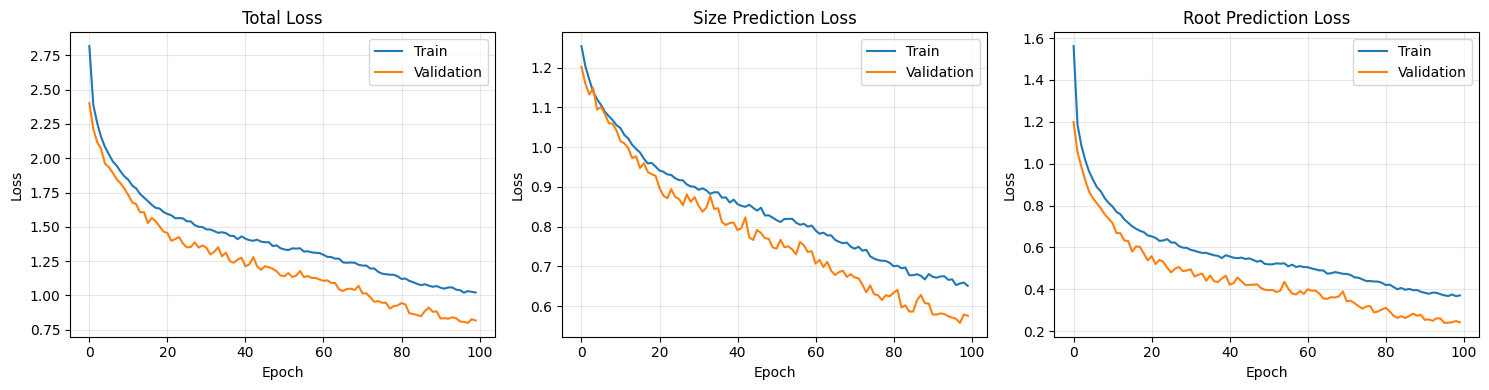

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title in zip(
    axes,
    [('train_loss', 'val_loss'),
     ('train_size_loss', 'val_size_loss'),
     ('train_root_loss', 'val_root_loss')],
    ['Total Loss', 'Size Prediction Loss', 'Root Prediction Loss'],
):
    ax.plot(history[key[0]], label='Train')
    ax.plot(history[key[1]], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Model

In [10]:
save_path = Path.cwd() / 'sequence_predictor_migrated.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history,
    'test_metrics': test_metrics,
}, save_path)
print(f'Model saved to {save_path}')

Model saved to c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\sequence_predictor_migrated.pt
